In [11]:
# ==========================================================
# IDC BREAST CANCER DATA PREPARATION
# SECTION 1 : IMPORT LIBRARIES
# ==========================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("="*70)
print("IDC BREAST CANCER DATA PREPARATION")
print("="*70)

IDC BREAST CANCER DATA PREPARATION


In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tayyabjamal","key":"4c4e548faa1371162544886771a72148"}'}

In [2]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d paultimothymooney/breast-histopathology-images

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images
License(s): CC0-1.0
100% 3.10G/3.10G [00:26<00:00, 126MB/s]



In [4]:
!unzip -oq breast-histopathology-images.zip

In [5]:
import os

print(os.listdir("/content"))

['.config', '14211', '15473', '9226', '15472', '15902', '9322', '9037', '8984', '12934', '13689', '12749', '12892', '16532', '9029', '15471', '14305', '8865', '13459', '16896', '13616', '15634', '9175', '8974', '12819', '9078', '12951', '12241', '10272', '12872', '13401', '12910', '9173', '9259', '9381', '10274', '10279', '12626', '12898', '15514', '12911', '15632', '14304', '15903', '10304', '16550', '12751', '15839', '9083', 'kaggle.json', '13018', '14209', '13692', '14191', '8975', '8914', '14153', '9126', '16570', '12876', '8867', '9178', '12882', '9077', '10301', '12905', '8918', '12897', '10253', '10290', '14081', '9257', '9225', '12929', '13025', '8913', '13693', '14321', '16531', '10305', '8951', '10276', '14213', '10257', '14155', '12891', '9266', '12895', '9261', '13666', '12868', '12948', '8950', '14082', '16085', '10261', '9325', '9320', '12890', '12750', '8959', '10300', '13024', '12820', '12871', '10258', '12826', '9125', '13916', '10292', '12896', '14210', '9073', '9250'

In [6]:
import os

DATASET_PATH = "/content/IDC_regular_ps50_idx5"

patients = sorted(os.listdir(DATASET_PATH))

print("="*60)
print("TOTAL PATIENTS :", len(patients))
print("="*60)

print("First Patient :", patients[0])

print("\nFolders inside first patient:")
print(os.listdir(os.path.join(DATASET_PATH, patients[0])))

TOTAL PATIENTS : 279
First Patient : 10253

Folders inside first patient:
['0', '1']


In [7]:
patient = patients[0]

print(os.listdir(os.path.join(DATASET_PATH, patient, "0"))[:5])

['10253_idx5_x1101_y1801_class0.png', '10253_idx5_x1301_y651_class0.png', '10253_idx5_x1451_y951_class0.png', '10253_idx5_x1651_y1151_class0.png', '10253_idx5_x401_y601_class0.png']


In [8]:
# ==========================================================
# SECTION 6 : COUNT TOTAL IMAGES
# ==========================================================

total_images = 0

class_0 = 0
class_1 = 0

for patient in patients:

    patient_path = os.path.join(DATASET_PATH, patient)

    if not os.path.isdir(patient_path):
        continue

    for cls in ["0", "1"]:

        class_path = os.path.join(patient_path, cls)

        if not os.path.exists(class_path):
            continue

        count = len([
            f for f in os.listdir(class_path)
            if f.endswith(".png")
        ])

        total_images += count

        if cls == "0":
            class_0 += count
        else:
            class_1 += count

print("="*70)
print("IDC DATASET INFORMATION")
print("="*70)

print("Class 0 (Non-IDC):", class_0)
print("Class 1 (IDC)    :", class_1)

print("\nTOTAL IMAGES :", total_images)

IDC DATASET INFORMATION
Class 0 (Non-IDC): 198738
Class 1 (IDC)    : 78786

TOTAL IMAGES : 277524


In [9]:
# ==========================================================
# SECTION 7 : DATASET DISTRIBUTION
# ==========================================================

print("="*70)
print("CLASS DISTRIBUTION")
print("="*70)

print(f"Non-IDC : {class_0}")
print(f"IDC     : {class_1}")

print()

print("Percentage")

print(f"Non-IDC : {100*class_0/total_images:.2f}%")
print(f"IDC     : {100*class_1/total_images:.2f}%")

CLASS DISTRIBUTION
Non-IDC : 198738
IDC     : 78786

Percentage
Non-IDC : 71.61%
IDC     : 28.39%


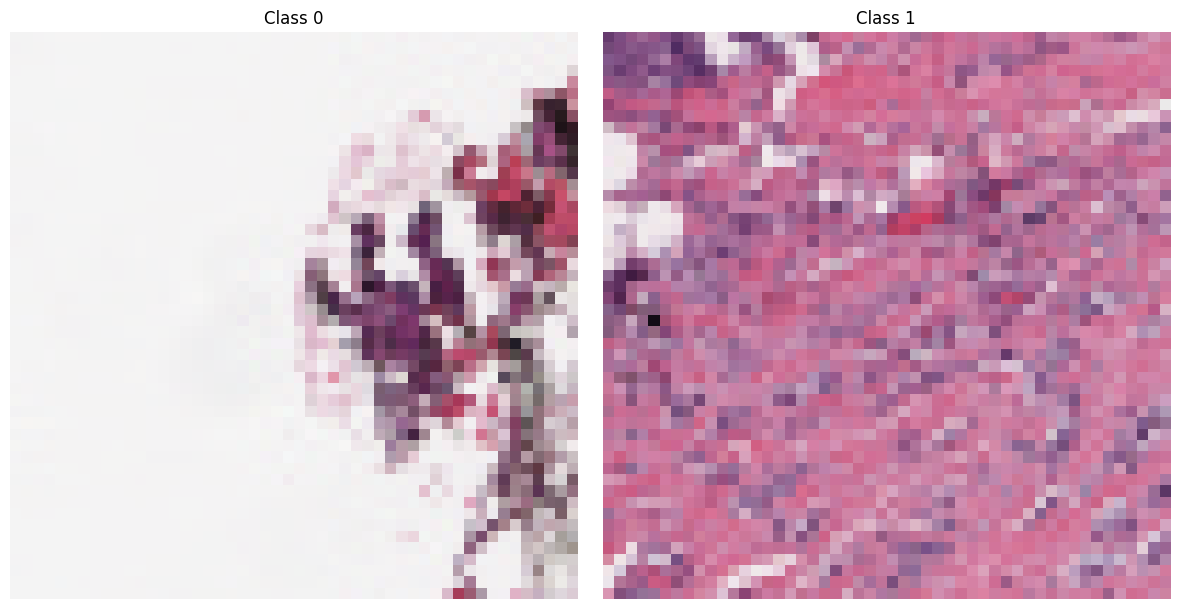

In [12]:
# ==========================================================
# SECTION 8 : DISPLAY RANDOM IMAGES
# ==========================================================

plt.figure(figsize=(12,6))

for i, cls in enumerate(["0","1"]):

    while True:

        patient = random.choice(patients)

        folder = os.path.join(DATASET_PATH, patient, cls)

        if os.path.exists(folder):

            images = [
                f for f in os.listdir(folder)
                if f.endswith(".png")
            ]

            if len(images) > 0:

                image = random.choice(images)

                img = Image.open(
                    os.path.join(folder,image)
                )

                plt.subplot(1,2,i+1)

                plt.imshow(img)

                plt.title(f"Class {cls}")

                plt.axis("off")

                break

plt.tight_layout()

plt.show()

In [13]:
# ==========================================================
# SECTION 9 : IMAGE SIZE
# ==========================================================

patient = patients[0]

sample = os.listdir(
    os.path.join(DATASET_PATH,patient,"0")
)[0]

img = Image.open(
    os.path.join(DATASET_PATH,patient,"0",sample)
)

print("="*70)

print("IMAGE SIZE")

print("="*70)

print(img.size)

IMAGE SIZE
(50, 50)


In [14]:
# ==========================================================
# SECTION 10 : DATASET READY
# ==========================================================

print("="*70)
print("IDC DATA PREPARATION COMPLETED")
print("="*70)

print("Patients :", len(patients))
print("Images   :", total_images)
print("Classes  : 2")

IDC DATA PREPARATION COMPLETED
Patients : 279
Images   : 277524
Classes  : 2
